# 03 — Gaussian Mixture Model (Model A — Probabilistic Baseline)
## CATIVE: Company Attractiveness & Talent Intelligence Viability Engine

### Theoretical Background

A Gaussian Mixture Model (GMM) assumes the data is generated by a mixture of K multivariate Gaussian distributions:

$$p(\mathbf{x}) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

where $\pi_k$ are mixing weights ($\sum_k \pi_k = 1$), $\boldsymbol{\mu}_k$ is the mean vector, and $\boldsymbol{\Sigma}_k$ is the covariance matrix of component $k$.

**Why GMM for CATIVE?** Hiring quality is unlikely to be perfectly separable by hard boundaries. GMM provides *soft* cluster assignments — a company can be 70% 'Growing', 25% 'High Desirability', 5% 'Emerging'. These posterior probabilities will be reused in Phase 3 as uncertainty features for the DL model.

### The EM Algorithm (Why it Converges)
Parameters $\theta = \{\pi_k, \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k\}$ are estimated by maximising the log-likelihood:

$$\mathcal{L}(\theta) = \sum_{n=1}^{N} \log \sum_{k=1}^{K} \pi_k \, \mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

Direct maximisation is intractable due to the log-of-sum. EM introduces latent variables $z_{nk}$ (responsibility of component k for point n):

**E-step**: Compute responsibilities
$$r_{nk} = \frac{\pi_k \, \mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)}{\sum_{j} \pi_j \, \mathcal{N}(\mathbf{x}_n \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)}$$

**M-step**: Update parameters using soft counts $N_k = \sum_n r_{nk}$
$$\boldsymbol{\mu}_k^{\text{new}} = \frac{1}{N_k} \sum_n r_{nk} \mathbf{x}_n, \quad \pi_k^{\text{new}} = \frac{N_k}{N}$$

**Convergence guarantee**: Each EM iteration is guaranteed to not decrease $\mathcal{L}$ (proven via Jensen's inequality on the concave log function). The algorithm converges to a local maximum of the likelihood.

**IID Assumption**: GMM assumes samples are independent and identically distributed — each company's review data is treated as an i.i.d. draw from the mixture. This holds reasonably for our dataset since companies were independently recruited.

### Covariance Types
- **`full`**: each component has its own unconstrained $\boldsymbol{\Sigma}_k$ (most expressive, most parameters)
- **`tied`**: all components share $\boldsymbol{\Sigma}$ (less flexible)
- **`diag`**: $\boldsymbol{\Sigma}_k$ is diagonal (features conditionally independent given component)
- **`spherical`**: $\boldsymbol{\Sigma}_k = \sigma_k^2 \mathbf{I}$ (most constrained)

We select covariance type via BIC (Bayesian Information Criterion), which penalises model complexity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, warnings
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from scipy.stats import multivariate_normal
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
PALETTE = {0: '#E07B54', 1: '#5B8DB8', 2: '#4CAF7D'}
LABEL_NAMES = ['Emerging', 'Growing', 'High Desirability']

X_full = pd.read_csv('../data/X_full.csv').values
y      = pd.read_csv('../data/y.csv').squeeze().values

print(f'X shape: {X_full.shape}, y shape: {y.shape}')
print(f'Classes: {np.unique(y, return_counts=True)}')

X shape: (1000, 80), y shape: (1000,)
Classes: (array([0, 1, 2]), array([333, 334, 333]))


## 1. PCA Reduction for GMM
High-dimensional full covariance GMMs suffer from numerical instability (singular covariance matrices) and the curse of dimensionality. We first reduce to the number of PCA components that explain 95% of variance.

In [2]:
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_full)
print(f'PCA reduced: {X_full.shape[1]} → {X_pca.shape[1]} components (95% variance)')
print(f'Variance explained by kept components: {pca.explained_variance_ratio_.sum()*100:.1f}%')

with open('../outputs/models/pca_gmm.pkl', 'wb') as f:
    pickle.dump(pca, f)

PCA reduced: 80 → 24 components (95% variance)
Variance explained by kept components: 95.1%


## 2. BIC Model Selection — K and Covariance Type

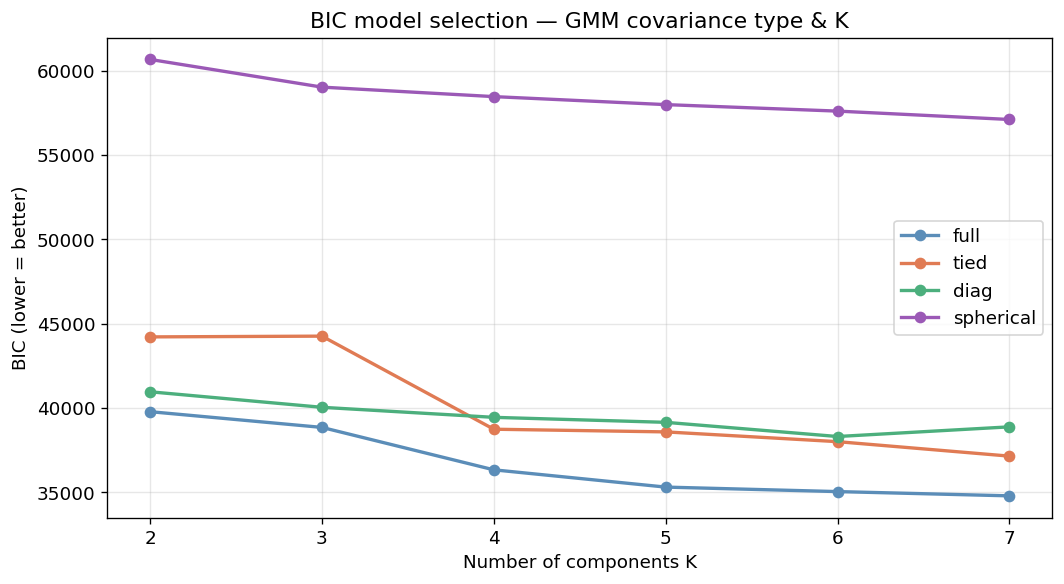


Best GMM config: K=7, covariance_type="full", BIC=34784
We override K=3 (matching our 3 ground-truth classes) if BIC-optimal K differs,
as the task requires mapping clusters to labels.

Final config: K=3, cov_type="full"


In [3]:
cov_types = ['full', 'tied', 'diag', 'spherical']
K_range   = range(2, 8)
bic_results = {}

for cov_type in cov_types:
    bics = []
    for k in K_range:
        gmm = GaussianMixture(n_components=k, covariance_type=cov_type,
                               max_iter=300, n_init=5, random_state=42)
        gmm.fit(X_pca)
        bics.append(gmm.bic(X_pca))
    bic_results[cov_type] = bics

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#5B8DB8', '#E07B54', '#4CAF7D', '#9B59B6']
for (cov_type, bics), color in zip(bic_results.items(), colors):
    ax.plot(list(K_range), bics, marker='o', label=cov_type, color=color, linewidth=2)
ax.set_xlabel('Number of components K')
ax.set_ylabel('BIC (lower = better)')
ax.set_title('BIC model selection — GMM covariance type & K')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/results/09_gmm_bic.png', bbox_inches='tight')
plt.show()

# Find best config
best_bic = np.inf
best_k, best_cov = None, None
for cov_type, bics in bic_results.items():
    for k, bic in zip(K_range, bics):
        if bic < best_bic:
            best_bic = bic
            best_k = k
            best_cov = cov_type

print(f'\nBest GMM config: K={best_k}, covariance_type="{best_cov}", BIC={best_bic:.0f}')
print(f'We override K=3 (matching our 3 ground-truth classes) if BIC-optimal K differs,')
print(f'as the task requires mapping clusters to labels.')
FINAL_K = 3
FINAL_COV = best_cov
print(f'\nFinal config: K={FINAL_K}, cov_type="{FINAL_COV}"')

## 3. Fit Final GMM & Inspect Convergence

In [4]:
gmm = GaussianMixture(
    n_components=FINAL_K,
    covariance_type=FINAL_COV,
    max_iter=500,
    n_init=10,
    tol=1e-4,
    random_state=42,
    verbose=1,
    verbose_interval=50
)
gmm.fit(X_pca)

print(f'\nConverged: {gmm.converged_}')
print(f'Iterations to convergence: {gmm.n_iter_}')
print(f'Final log-likelihood: {gmm.lower_bound_:.4f}')
print(f'\nMixing weights π_k: {gmm.weights_.round(3)}')
print(f'Component means (first 3 dims shown):')
print(gmm.means_[:, :3].round(3))

Initialization 0
Initialization converged.
Initialization 1
Initialization converged.
Initialization 2
Initialization converged.
Initialization 3
Initialization converged.
Initialization 4
Initialization converged.
Initialization 5
Initialization converged.
Initialization 6
Initialization converged.
Initialization 7
Initialization converged.
Initialization 8
Initialization converged.
Initialization 9
Initialization converged.

Converged: True
Iterations to convergence: 30
Final log-likelihood: -15.4424

Mixing weights π_k: [0.267 0.485 0.248]
Component means (first 3 dims shown):
[[-0.348 -0.815  0.217]
 [ 0.158 -0.536 -0.062]
 [ 0.064  1.923 -0.112]]


## 4. Cluster → Label Mapping (Hungarian-style greedy assignment)

In [5]:
cluster_preds = gmm.predict(X_pca)

# For each GMM cluster, find the most frequent ground-truth label
from scipy.stats import mode
cluster_to_label = {}
for cluster_id in range(FINAL_K):
    mask = cluster_preds == cluster_id
    true_labels_in_cluster = y[mask]
    most_common = mode(true_labels_in_cluster, keepdims=True).mode[0]
    cluster_to_label[cluster_id] = most_common
    print(f'Cluster {cluster_id} → label {most_common} ({LABEL_NAMES[most_common]})')
    print(f'  Distribution: {np.bincount(true_labels_in_cluster, minlength=3)}')

y_pred_gmm = np.array([cluster_to_label[c] for c in cluster_preds])

Cluster 0 → label 0 (Emerging)
  Distribution: [97 82 87]
Cluster 1 → label 2 (High Desirability)
  Distribution: [160 152 174]
Cluster 2 → label 1 (Growing)
  Distribution: [ 76 100  72]


## 5. GMM Classification Performance

GMM Macro-F1: 0.3641

Classification Report:
                   precision    recall  f1-score   support

         Emerging       0.36      0.29      0.32       333
          Growing       0.40      0.30      0.34       334
High Desirability       0.36      0.52      0.42       333

         accuracy                           0.37      1000
        macro avg       0.38      0.37      0.36      1000
     weighted avg       0.38      0.37      0.36      1000



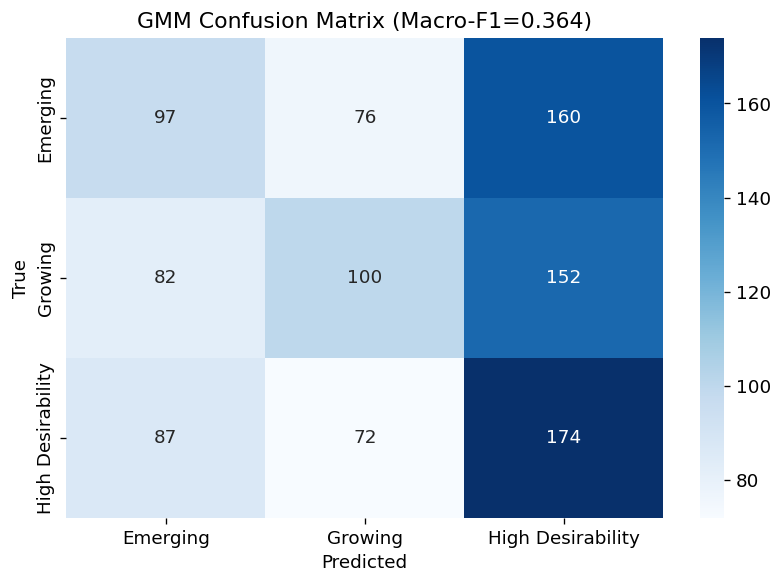

In [6]:
macro_f1 = f1_score(y, y_pred_gmm, average='macro')
print(f'GMM Macro-F1: {macro_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y, y_pred_gmm, target_names=LABEL_NAMES))

cm = confusion_matrix(y, y_pred_gmm)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'GMM Confusion Matrix (Macro-F1={macro_f1:.3f})')
plt.tight_layout()
plt.savefig('../outputs/results/10_gmm_confusion_matrix.png', bbox_inches='tight')
plt.show()

## 6. Visualise GMM in 2D PCA Space

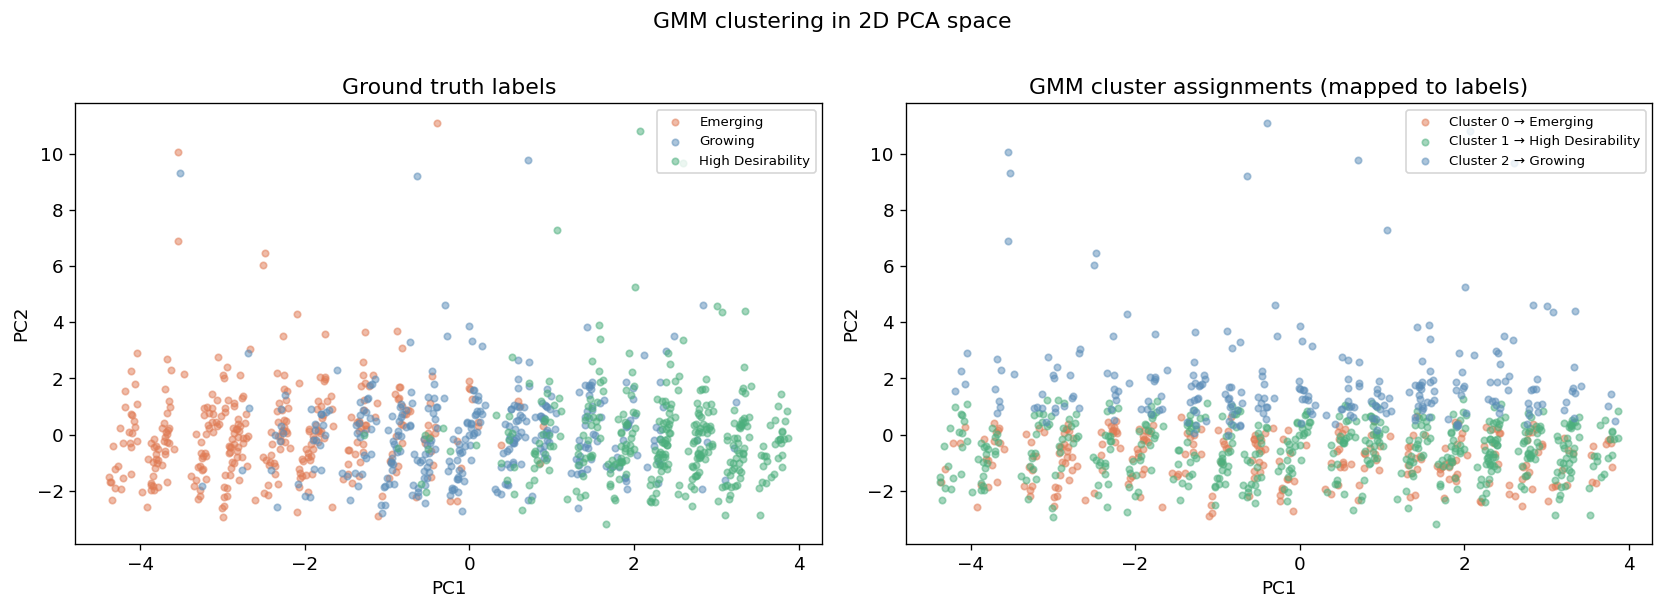

In [7]:
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ground truth
for lbl_idx, lbl_name in enumerate(LABEL_NAMES):
    mask = y == lbl_idx
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=list(PALETTE.values())[lbl_idx], label=lbl_name, alpha=0.5, s=15)
axes[0].set_title('Ground truth labels')
axes[0].legend(fontsize=8)

# GMM predictions
for cluster_id in range(FINAL_K):
    mask = cluster_preds == cluster_id
    mapped_lbl = cluster_to_label[cluster_id]
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=list(PALETTE.values())[mapped_lbl], alpha=0.5, s=15,
                    label=f'Cluster {cluster_id} → {LABEL_NAMES[mapped_lbl]}')
axes[1].set_title('GMM cluster assignments (mapped to labels)')
axes[1].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.suptitle('GMM clustering in 2D PCA space', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/results/11_gmm_2d.png', bbox_inches='tight')
plt.show()

## 7. Save GMM Posteriors for Phase 3 (Hybrid Integration)
The soft posterior probabilities $r_{nk}$ represent the model's *uncertainty* about each company's cluster. In Phase 3, these will be concatenated as 3 additional features to the DL model's input — providing probabilistic context from the AML model.

In [8]:
posteriors = gmm.predict_proba(X_pca)  # shape: (1000, 3)
posteriors_df = pd.DataFrame(posteriors,
                              columns=[f'gmm_posterior_{i}' for i in range(FINAL_K)])
posteriors_df.to_csv('../data/gmm_posteriors.csv', index=False)

with open('../outputs/models/gmm_model.pkl', 'wb') as f:
    pickle.dump(gmm, f)

print(f'Saved GMM model and posteriors.')
print(f'Posteriors shape: {posteriors.shape}')
print(f'Mean entropy per sample: {(-posteriors * np.log(posteriors + 1e-10)).sum(axis=1).mean():.4f}')
print(f'(Higher entropy = more uncertainty; these uncertain samples are hardest to classify.)')

print('\n=== ABLATION NOTE ===')
print(f'GMM alone Macro-F1: {macro_f1:.4f}')
print('This serves as the probabilistic baseline (Model A) in the ablation table.')
print('Expected: SVM (Model B) and XGBoost (Model C) will significantly outperform this,')
print('demonstrating the value of supervised discriminative learning.')

Saved GMM model and posteriors.
Posteriors shape: (1000, 3)
Mean entropy per sample: 0.0100
(Higher entropy = more uncertainty; these uncertain samples are hardest to classify.)

=== ABLATION NOTE ===
GMM alone Macro-F1: 0.3641
This serves as the probabilistic baseline (Model A) in the ablation table.
Expected: SVM (Model B) and XGBoost (Model C) will significantly outperform this,
demonstrating the value of supervised discriminative learning.
